# Caso de Estudio: Predicción de Resistencia del Hormigón

**1. Contexto del Problema**

En la ingeniería civil, la calidad del hormigón es crítica para la seguridad de edificios y puentes. El método tradicional para verificar su resistencia es lento y costoso:

- Se diseña la mezcla.

- Se crean cilindros de prueba.

- Se espera 28 días de curado.

- Se rompen los cilindros en una prensa hidráulica para medir su resistencia a la compresión (en MPa).

El Problema: Si la mezcla falla a los 28 días, hemos perdido un mes entero de obra y mucho dinero. El Objetivo: Crear un modelo de Machine Learning capaz de predecir la resistencia final del hormigón basándose únicamente en su "receta" (ingredientes y edad), sin tener que esperar a romperlo.

## Dataset

Utilizaremos datos reales donados por el Prof. I-Cheng Yeh (Universidad de Chu-Hua), provenientes de 1030 ensayos de laboratorio.

El Reto Matemático: La química del cemento es compleja y no lineal. La relación entre la cantidad de agua y la resistencia no es una línea recta. Por eso, modelos simples como la Regresión Lineal suelen fallar, mientras que algoritmos basados en árboles (como Random Forest) pueden capturar estas reacciones químicas complejas.

### Variables

**Variables Predictoras ($X$):**

- Cemento (Cement): Kg en un metro cúbico ($m^3$) de mezcla.
- Escoria de Alto Horno (Blast Furnace Slag): Residuo industrial usado como aditivo.
- Ceniza Volante (Fly Ash): Partículas de la quema de carbón, mejora la durabilidad.
- Agua (Water): Componente vital para la hidratación.
- Superplastificante (Superplasticizer): Químico para reducir agua manteniendo fluidez.
- Agregado Grueso (Coarse Aggregate): Grava/Piedras.
- Agregado Fino (Fine Aggregate): Arena.
- Edad (Age): Días de curado (de 1 a 365 días).

**Variable Objetivo ($y$):**

- Resistencia a la Compresión (Concrete compressive strength): Medida en MegaPascales (MPa). Es lo que queremos predecir.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# !pip install xgboost
from xgboost import XGBRegressor
# !pip install lightgbm
from lightgbm import LGBMRegressor

In [2]:
#from google.colab import files
#files.upload()

#data = pd.read_csv('Country-data.csv')

In [3]:
df = pd.read_csv('data/concrete.csv')
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [4]:
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [5]:
df.shape

(1030, 9)

In [6]:
# 1. Ver los nombres originales
print("Columnas originales:", df.columns.tolist())

# 2. Renombrar columnas en español
df.columns = ['Cemento', 'Escoria', 'Ceniza', 'Agua', 'Superplast', 'Grano_Grueso', 'Grano_Fino', 'Edad', 'Resistencia']

df.head()

Columnas originales: ['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg', 'fineagg', 'age', 'strength']


,Cemento,Escoria,Ceniza,Agua,Superplast,Grano_Grueso,Grano_Fino,Edad,Resistencia
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


### Variable objetivo

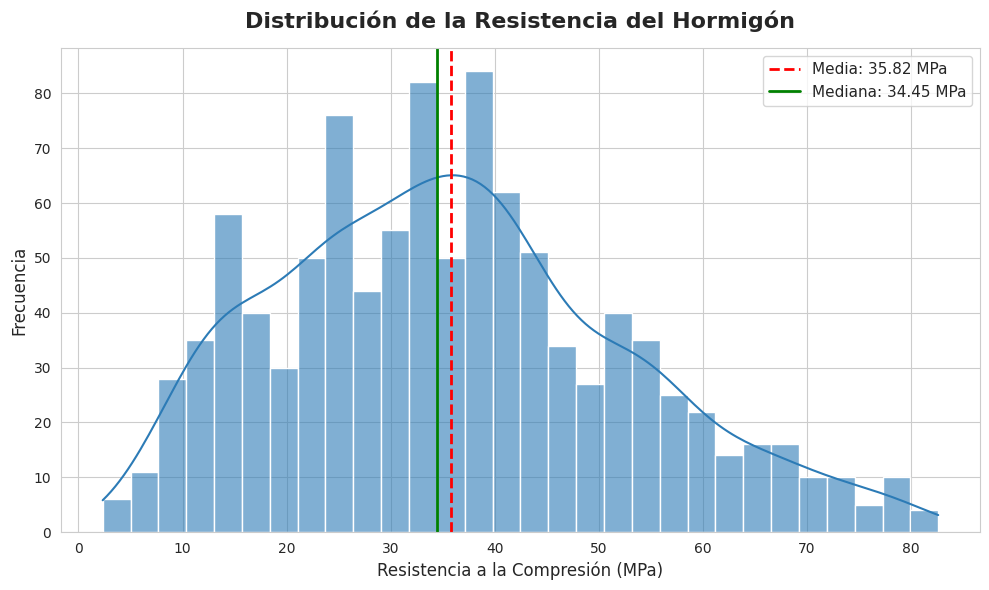

Asimetría (Skewness): 0.42
-> La distribución es bastante SIMÉTRICA (Cercana a Normal).


In [7]:
# Configuración de estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# 1. Crear el Histograma con la curva de densidad (KDE)
# bins=30: Divide los datos en 30 barras para tener buen detalle
sns.histplot(data=df, x='Resistencia', kde=True, color='#2c7bb6', bins=30, alpha=0.6)

# 2. Calcular Media y Mediana
media = df['Resistencia'].mean()
mediana = df['Resistencia'].median()

# 3. Dibujar líneas verticales
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f} MPa')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f} MPa')

# 4. Títulos y Etiquetas Profesionales
plt.title('Distribución de la Resistencia del Hormigón', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Resistencia a la Compresión (MPa)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# 5. Añadir leyenda
plt.legend(fontsize=11)

# Mostrar gráfico
plt.tight_layout()
plt.show()


print(f"Asimetría (Skewness): {df['Resistencia'].skew():.2f}")
if -0.5 < df['Resistencia'].skew() < 0.5:
    print("-> La distribución es bastante SIMÉTRICA (Cercana a Normal).")
else:
    print("-> La distribución está SESGADA (No es perfectamente Normal).")

- Asimetría (Skewness)(0.42): cae dentro de la "zona segura". Significa que tenemos una variedad de hormigones muy equilibrada. No estamos analizando solo hormigones débiles ni solo súper-resistentes.

- La Media es ligeramente mayor que la Mediana ($35.82 > 34.45$).

    - ¿Qué significa físicamente?La media es "sensible" a los valores extremos. El hecho de que sea un poco más alta significa que hay unos pocos hormigones de muy alta resistencia (los de 80 MPa que vimos en el máximo) que están "tirando" del promedio hacia arriba.La Diferencia: Es solo de 1.37 MPa.En ingeniería civil, una diferencia de 1 MPa es despreciable (es margen de error de laboratorio). Si la diferencia fuera de 10 o 15 MPa, tendríamos un problema de sesgo grave.
 
- Con Random Forest: Al Random Forest no le importa la forma de la campana.

    - ¿Por qué? Porque el bosque no usa fórmulas matemáticas globales. El bosque hace preguntas de "Cortar y Separar":

    - Como trabaja por secciones (cajas), puede modelar perfectamente una distribución deforme sin necesidad de transformar los datos con logaritmos.

In [8]:
# Verificar valores nulos
print("--- Recuento de Valores Nulos ---")
print(df.isnull().sum())

--- Recuento de Valores Nulos ---
Cemento         0
Escoria         0
Ceniza          0
Agua            0
Superplast      0
Grano_Grueso    0
Grano_Fino      0
Edad            0
Resistencia     0
dtype: int64


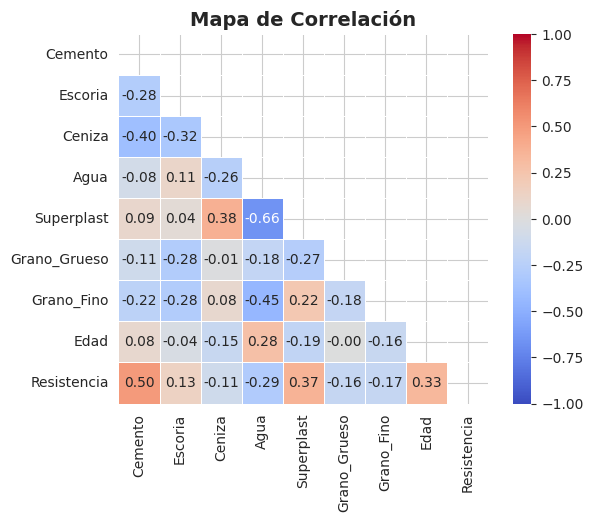

In [9]:
# PASO 4: Calcular la correlación
corr = df.corr()

# Máscara para el triángulo superior
mask = np.triu(np.ones_like(corr, dtype=bool))
# Mapa de Calor (Heatmap)
sns.heatmap(corr, 
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            vmax=1, vmin=-1, 
            linewidths=0.5, 
            square=True)

plt.title('Mapa de Correlación', fontsize=14, fontweight='bold')
plt.show()

#### 1. Los "Constructores" (Correlación Positiva) Son las variables que, al aumentar, suben la resistencia.
   
- **Cemento (0.49):**
   - Es la variable más influyente linealmente.
   - Física: El cemento es el aglomerante principal. Cuanto más pones, más fuerte es la matriz.

- **Superplastificante (0.36):**
   - Tiene una correlación alta y positiva.
   - Física: Este aditivo permite que el hormigón fluya sin añadir agua extra. Al reducir la necesidad de agua, densifica la mezcla y dispara la resistencia.
     
- **Edad (0.32):**
   - El Factor Tiempo.
   - Física: El hormigón no se seca, fragua. Es una reacción química que continúa durante meses. El modelo entiende que un bloque con 90 días es más fuerte que uno con 3 días.

#### 2. El "Destructor" (Correlación Negativa)

- **Agua (-0.29):**
   - Es la correlación negativa más fuerte.
   - Física (Ley de Abrams): El agua es necesaria para la mezcla, pero el exceso de agua se evapora dejando poros (aire) dentro del bloque. Más poros = Más grietas = Menos resistencia.

#### 3. Los "Rellenos" (Correlaciones Débiles)

- **Ceniza (-0.10) y Agregados (-0.16):**
    - Tienen valores bajos y negativos.Interpretación: Estos materiales son "relleno" o sustitutos parciales. Si aumentas la cantidad de piedras (agregados) en un $m^3$, proporcionalmente estás quitando pasta de cemento, por lo que la resistencia baja ligeramente.

In [10]:
# Definir X (Variables predictoras) e y (Objetivo)
X = df.drop('Resistencia', axis=1)
feature_names = X.columns
y = df['Resistencia']

In [11]:
# Dividir en Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Test: {X_test.shape[0]} muestras")

Entrenamiento: 824 muestras
Test: 206 muestras


In [12]:
# Validación Cruzada (KFold estándar)
# Usamos KFold normal porque estamos prediciendo números, no categorías.
cv_regresion = KFold(n_splits=5, shuffle=True, random_state=42)

## Funciones auxiliares

In [13]:
# 1. Función auxiliar para calcular métricas
def calcular_metricas(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    
    # Métricas de Ingeniería
    mae = mean_absolute_error(y_test, y_pred)     # Error absoluto medio
    mse = mean_squared_error(y_test, y_pred)      # Error cuadrático medio medio
    rmse = np.sqrt(mse)                           # Raíz del error cuadrático
    r2 = r2_score(y_test, y_pred)                 # Coeficiente de determinación
    
    return {
        'Modelo': nombre_modelo,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [14]:
# Gráfico Individual Real vs. Predicho ---
def plot_real_vs_pred(model, X_test, y_test, model_name, color='blue'):
    """Genera un scatter plot de la realidad frente a la predicción de un modelo."""
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(8, 8))
    
    # Puntos de dispersión
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color=color, s=60)
    
    # Línea de perfección (y=x)
    m = max(y_test.max(), y_pred.max())
    plt.plot([0, m], [0, m], 'r--', lw=2, label='Predicción Perfecta')
    
    plt.title(f'Validación: {model_name} (Realidad vs Estimación)', fontsize=14, fontweight='bold')
    plt.xlabel('Resistencia Real (MPa)', fontsize=12)
    plt.ylabel(f'Predicción {model_name} (MPa)', fontsize=12)
    plt.legend()
    plt.axis('square')
    plt.show()

In [15]:
# Función para dar una lista de las caracteristicas más importantes de cada modelo
def get_top_features(model, feature_names, top_n=10):
    """
    Extrae, normaliza y devuelve las N características más importantes de un modelo.
    
    Args:
        model: Objeto de modelo entrenado (debe tener 'feature_importances_').
        feature_names: Lista de nombres de las características (columnas de X_train).
        top_n: Número de características a devolver.
        
    Returns:
        pd.Series con las características y su importancia normalizada.
    """
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        # Normalización
        total_importance = importances.sum()
        if total_importance > 0:
            importances_normalized = importances / total_importance
        else:
            importances_normalized = importances
            
        # Crear Serie, ordenar y seleccionar las Top N
        feat_imp = pd.Series(importances_normalized, index=feature_names).sort_values(ascending=False)
        
        return feat_imp.head(top_n)
    else:
        print(f"El modelo no soporta 'feature_importances_'.")
        return pd.Series()

In [16]:
# Gráfico de Importancia de Características
def plot_feature_importance(model, feature_names, model_name, palette='viridis'):
    """Extrae y grafica la importancia de las variables para modelos basados en árboles."""
    
    # Verificar si el modelo tiene el atributo de importancia
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        
        # Crear DataFrame y ordenar
        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)
        
        plt.title(f'Ranking de Variables: {model_name}', fontsize=14, fontweight='bold')
        plt.xlabel('Importancia Relativa', fontsize=12)
        plt.ylabel('Ingredientes / Variables', fontsize=12)
        plt.show()
    else:
        print(f"El modelo {model_name} no soporta 'feature_importances_'")

In [17]:
# Grafico para diagnosticar sesgos
def plot_residuals(model, X_test, y_test, model_name, color='purple'):
    """
    Grafica los residuos (Error = Real - Predicho) para diagnosticar sesgos.
    """
    # 1. Predecir
    y_pred = model.predict(X_test)
    
    # 2. Calcular el error (Residuo)
    residuos = y_test - y_pred
    
    # 3. Graficar
    plt.figure(figsize=(10, 6))
    
    # Scatter plot: Eje X = Valor Real, Eje Y = Cuánto nos equivocamos
    sns.scatterplot(x=y_test, y=residuos, color=color, alpha=0.6, s=60)
    
    # Línea de referencia (El cero perfecto)
    plt.axhline(0, color='black', linestyle='--', lw=2, label='Error Cero (Perfecto)')
    
    # Bandas de confianza visual (opcional, ej. +/- 5 MPa)
    plt.axhline(5, color='gray', linestyle=':', alpha=0.5)
    plt.axhline(-5, color='gray', linestyle=':', alpha=0.5)
    
    plt.title(f'Diagnóstico de Residuos: {model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Resistencia REAL (MPa)', fontsize=12)
    plt.ylabel('Error (Real - Predicho) [MPa]', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()


In [18]:
# Inicializar la tabla de resultados
historial_modelos = []

## RANDOM FOREST

In [19]:
# Hiperparámetros 
dict_params = {
    "n_estimators": [100, 200],          # Número de árboles
    "max_depth": [10, 20, None],         # Profundidad (Evitar overfitting)
    "min_samples_split": [2, 5],         # Cuántos datos mínimos para dividir un nodo
    "min_samples_leaf": [1, 2],          # Cuántos datos mínimos en una hoja final
    "max_features": ["sqrt", 1.0],       # Cuántas variables mirar (1.0 = todas)
    "criterion": ["squared_error", "absolute_error"]
}

In [20]:
# Configuración del GridSearch
# scoring='r2': Queremos el modelo que mejor explique la varianza (cercano a 1.0)
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=dict_params,
    cv=cv_regresion,          # Usamos el KFold estándar que definimos antes
    n_jobs=-1,                # Usar todos los procesadores
    verbose=1,
    scoring='r2',             # Optimizamos R cuadrado
    return_train_score=True
)

In [21]:
# Entrenamiento del modelo
print("--- Entrenando Random Forest (esto puede tardar unos segundos) ---")
grid_rf.fit(X_train, y_train)

# Guardamos el mejor modelo en una variable limpia
best_rf = grid_rf.best_estimator_

print(f"\nMejores parámetros: {grid_rf.best_params_}")
print(f"Mejor R2 en validación cruzada: {grid_rf.best_score_:.4f}")

--- Entrenando Random Forest (esto puede tardar unos segundos) ---
Fitting 5 folds for each of 96 candidates, totalling 480 fits

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 20, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor R2 en validación cruzada: 0.9065


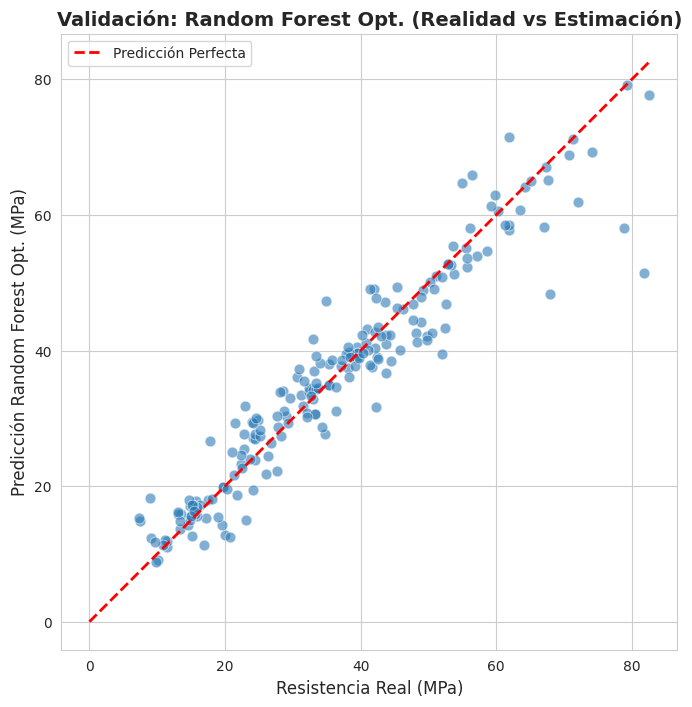

In [22]:
# Gráfico Realidad vs. Predicción
plot_real_vs_pred(best_rf, X_test, y_test, "Random Forest Opt.", color='#2c7bb6')

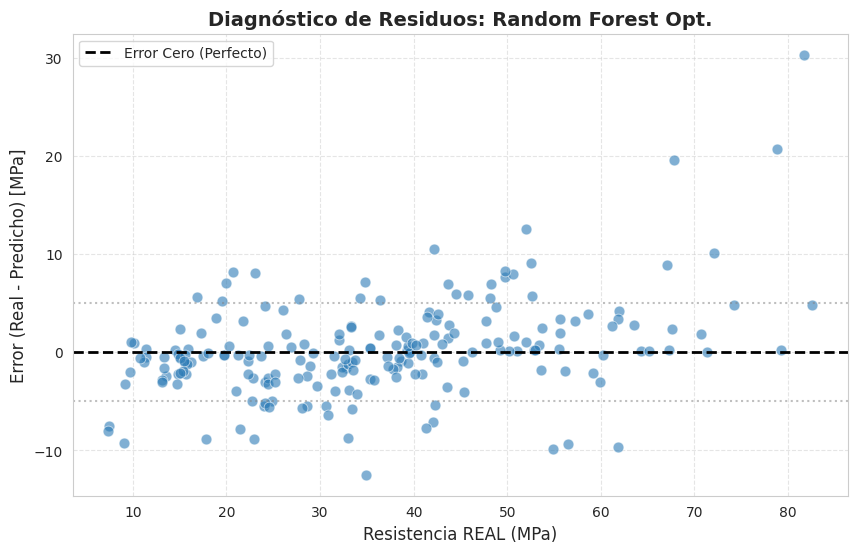

In [23]:
# Gráfico para diagnosticar residuos
plot_residuals(best_rf, X_test, y_test, "Random Forest Opt.", color='#2c7bb6')

In [24]:
get_top_features(best_rf, feature_names, top_n=5)

Edad          0.254034
Cemento       0.253455
Agua          0.110362
Superplast    0.101335
Escoria       0.098930
dtype: float64

/tmp/ipykernel_6713/2240478280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


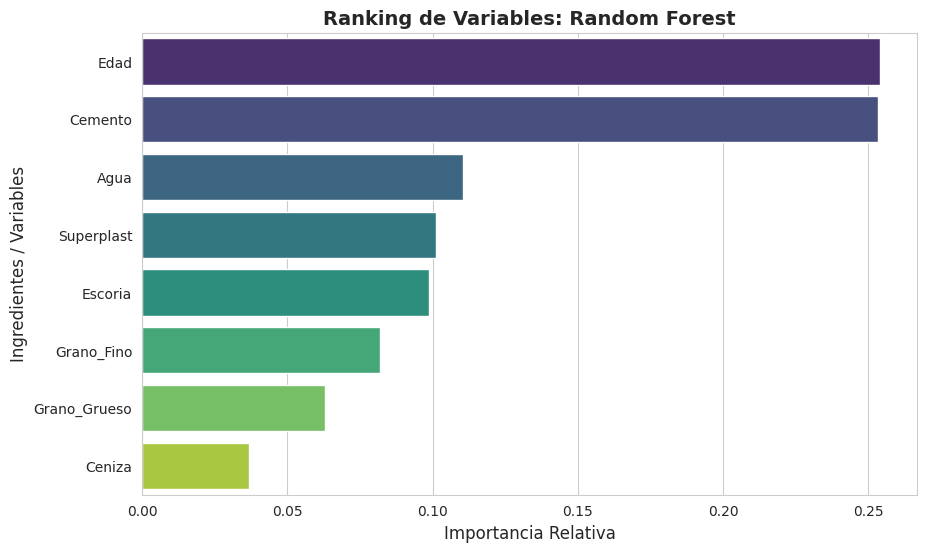

In [25]:
# Gráfico de Importancia de Características
plot_feature_importance(best_rf, X_train.columns, "Random Forest", palette='viridis')

In [26]:
# Calcular las metricas
metricas_rf = calcular_metricas(best_rf, X_test, y_test, "Random Forest")
historial_modelos.append(metricas_rf)

In [27]:
# Mostrar el Marcador Actual
df_comparativa = pd.DataFrame(historial_modelos)
print(df_comparativa)

          Modelo  MAE (Error Medio)  RMSE (Error Grande)  R2 (Calidad)
0  Random Forest           3.299878             4.998944      0.912667


## XGBOOST

In [28]:
# Hiperparámetros 
dict_params_xgb = {
    "n_estimators": [100, 500],      # XGBoost suele necesitar más árboles si el learning_rate es bajo
    "learning_rate": [0.01, 0.1],    # Velocidad de corrección
    "max_depth": [3, 5, 7],          # Profundidad (Cuidado con el overfitting aquí)
    "subsample": [0.8],              # Usar solo una parte de los datos para evitar memorizar
    "objective": ['reg:squarederror', 'reg:absoluteerror']
}

In [29]:
# Configurar GridSearch para XGBoost
grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1), # XGBoost paralela por defecto
    param_grid=dict_params_xgb,
    cv=cv_regresion,
    verbose=1,
    scoring='r2',
    return_train_score=True
)

In [30]:
# Entrenamiento del modelo
print("Entrenando XGBoost")
grid_xgb.fit(X_train, y_train)

Entrenando XGBoost
Fitting 5 folds for each of 24 candidates, totalling 120 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 500], 'objective': ['reg:squarederror', 'reg:absoluteerror'], ...}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'reg:squarederror'


In [31]:
# Extraer el mejor modelo
best_xgb = grid_xgb.best_estimator_

print(f"\nMejores parámetros XGB: {grid_xgb.best_params_}")
print(f"Mejor R2 en validación: {grid_xgb.best_score_:.4f}")


Mejores parámetros XGB: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500, 'objective': 'reg:squarederror', 'subsample': 0.8}
Mejor R2 en validación: 0.9338


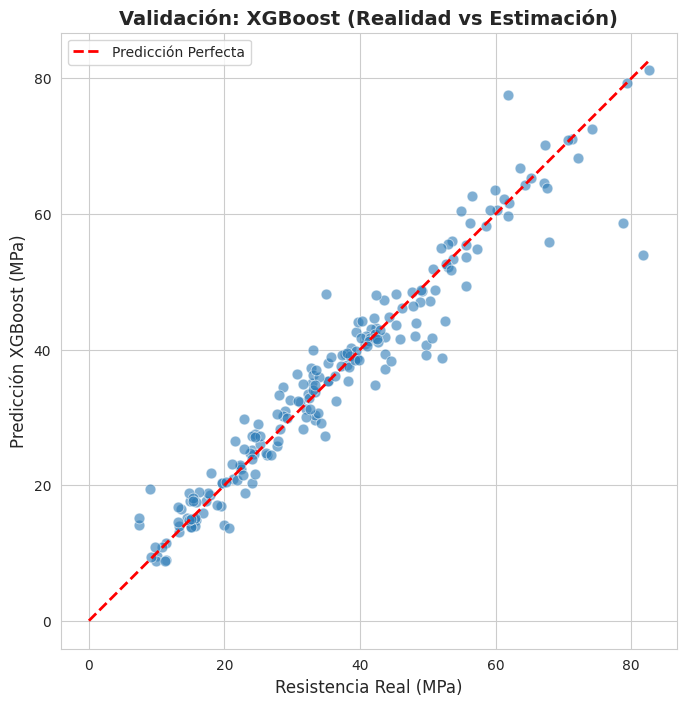

In [32]:
# Gráfico Realidad vs. Predicción
plot_real_vs_pred(best_xgb, X_test, y_test, "XGBoost", color='#2c7bb6')

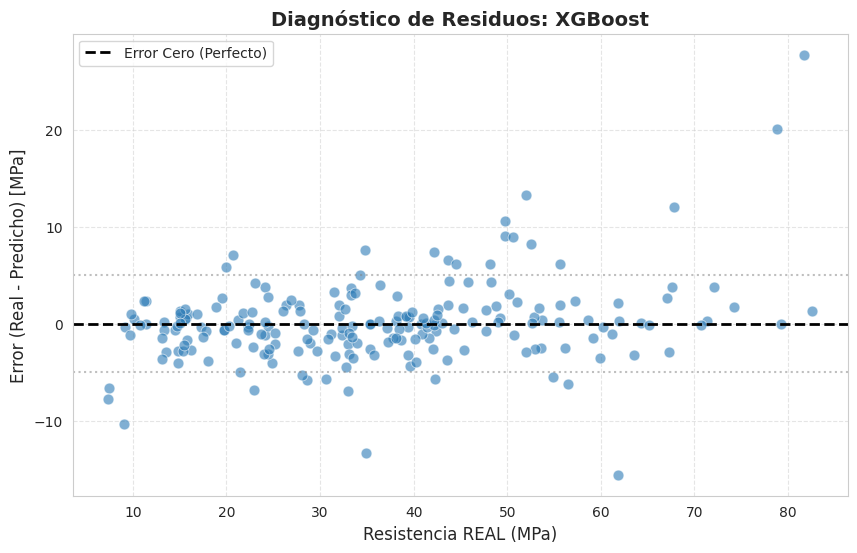

In [33]:
# Gráfico para diagnosticar residuos
plot_residuals(best_xgb, X_test, y_test, "XGBoost", color='#2c7bb6')

In [34]:
get_top_features(best_xgb, feature_names, top_n=5)

Cemento       0.220668
Edad          0.191802
Superplast    0.183485
Escoria       0.141120
Agua          0.106922
dtype: float32

/tmp/ipykernel_6713/2240478280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


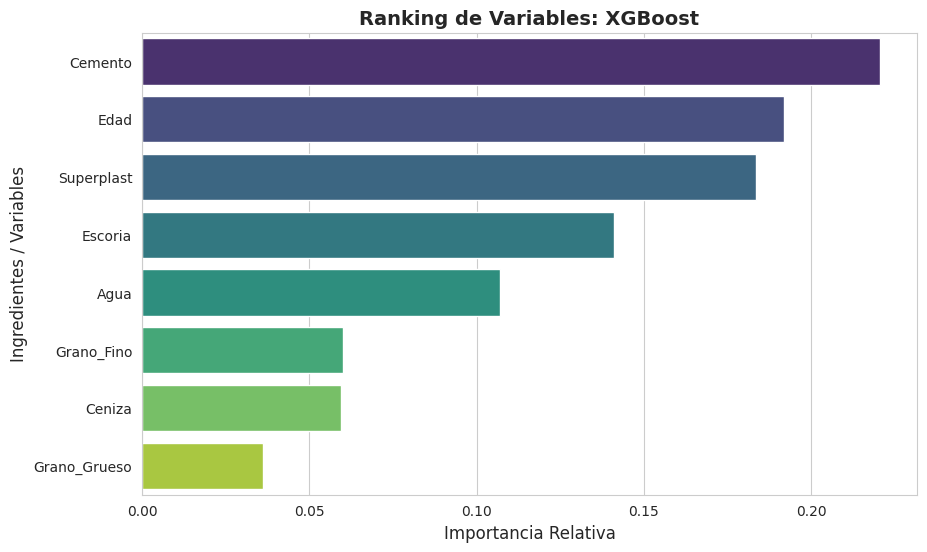

In [35]:
# Gráfico de Importancia de Características
plot_feature_importance(best_xgb, X_train.columns, "XGBoost", palette='viridis')

In [36]:
# Evaluar XGBoost 
metricas_xgb = calcular_metricas(best_xgb, X_test, y_test, "XGBoost")

# Añadir al historial (Marcador)
historial_modelos.append(metricas_xgb)

In [37]:
# Mostrar la tabla actualizada
df_comparativa = pd.DataFrame(historial_modelos)
df_comparativa_final = df_comparativa.sort_values(by='R2 (Calidad)', ascending=False)

df_comparativa_final

,Modelo,MAE (Error Medio),RMSE (Error Grande),R2 (Calidad)
1,XGBoost,2.710363,4.352416,0.933796
0,Random Forest,3.299878,4.998944,0.912667


## LightGBM

In [38]:
# Hiperparámetros
# 'num_leaves': Es el parámetro MÁS importante en LGBM (controla la complejidad)
# 'learning_rate': Velocidad de aprendizaje (típico entre 0.01 y 0.1)
dict_params_lgbm = {
    "n_estimators": [100, 500],     # Número de árboles
    "learning_rate": [0.01, 0.1],   # Paso de corrección
    "num_leaves": [20, 31],         # Hojas máximas por árbol (31 es default)
    "max_depth": [-1, 10],          # -1 significa sin límite (confiamos en num_leaves)
    "reg_alpha": [0, 0.1],          # Regularización L1 (para evitar ruido)
    "objective": ['regression', 'mae']
}

In [39]:
# Configuración del GridSearch
grid_lgbm = GridSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1), # verbose=-1 silencia advertencias
    param_grid=dict_params_lgbm,
    cv=cv_regresion,           # Usamos el mismo KFold que antes
    n_jobs=-1,
    verbose=1,
    scoring='r2',
    return_train_score=True
)

In [40]:
# Entrenamiento
print("Entrenando LightGBM")
grid_lgbm.fit(X_train, y_train)

Entrenando LightGBM
Fitting 5 folds for each of 64 candidates, totalling 320 fits


,estimator,"LGBMRegressor...2, verbose=-1)"
,param_grid,"{'learning_rate': [0.01, 0.1], 'max_depth': [-1, 10], 'n_estimators': [100, 500], 'num_leaves': [20, 31], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,boosting_type,'gbdt'


In [41]:
# Guardar el mejor modelo
best_lgbm = grid_lgbm.best_estimator_

print(f"\nMejores parámetros LGBM: {grid_lgbm.best_params_}")
print(f"Mejor R2 en validación: {grid_lgbm.best_score_:.4f}")


Mejores parámetros LGBM: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 500, 'num_leaves': 20, 'objective': 'regression', 'reg_alpha': 0}
Mejor R2 en validación: 0.9325


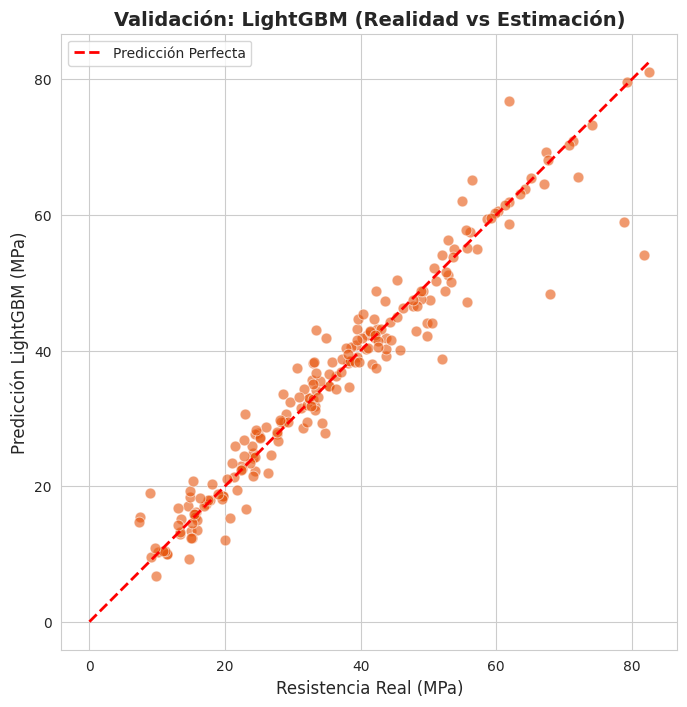

In [42]:
# Gráfico Realidad vs. Predicción
plot_real_vs_pred(best_lgbm, X_test, y_test, "LightGBM", color='#e6550d')

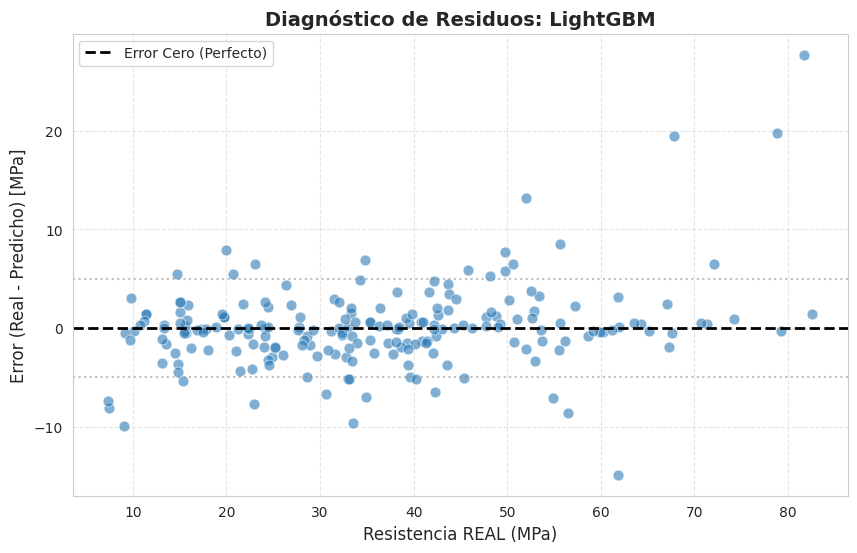

In [43]:
# Gráfico para diagnosticar residuos
plot_residuals(best_lgbm, X_test, y_test, "LightGBM", color='#2c7bb6')

In [44]:
get_top_features(best_lgbm, feature_names, top_n=5)

Cemento         0.180056
Grano_Grueso    0.162610
Agua            0.140750
Grano_Fino      0.139565
Edad            0.138057
dtype: float64

/tmp/ipykernel_6713/2240478280.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette=palette)


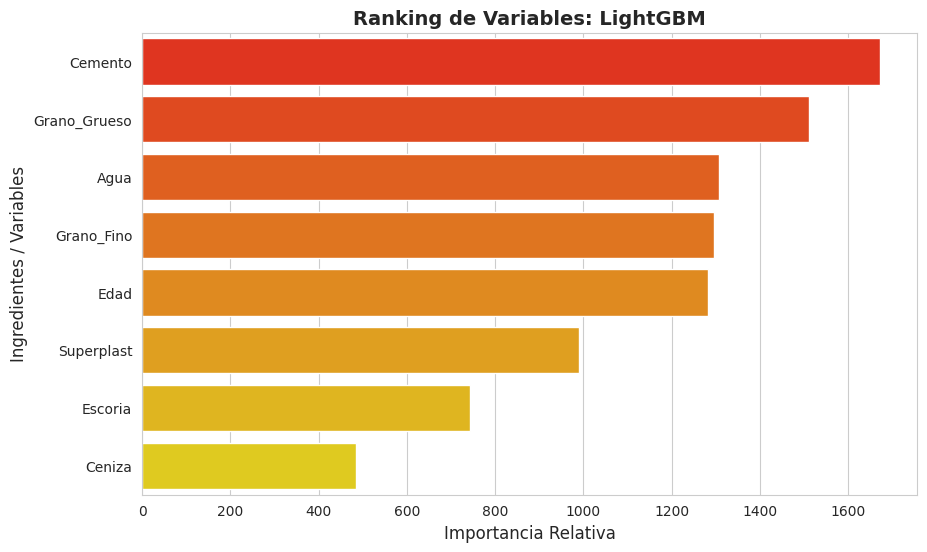

In [45]:
# Gráfico de Importancia de Características
plot_feature_importance(best_lgbm, X_train.columns, "LightGBM", palette='autumn')

In [46]:
# Calcular notas y guardar
metricas_lgbm = calcular_metricas(best_lgbm, X_test, y_test, "LightGBM")
historial_modelos.append(metricas_lgbm)


In [47]:
# Mostrar la Tabla de Resultados Actualizada 
df_resultados = pd.DataFrame(historial_modelos).sort_values(by='R2 (Calidad)', ascending=False)
df_resultados

,Modelo,MAE (Error Medio),RMSE (Error Grande),R2 (Calidad)
1,XGBoost,2.710363,4.352416,0.933796
2,LightGBM,2.632990,4.359104,0.933592
0,Random Forest,3.299878,4.998944,0.912667


## Regresión Lineal

In [48]:
print("--- Entrenando Regresión Lineal (Baseline) ---")
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

--- Entrenando Regresión Lineal (Baseline) ---


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


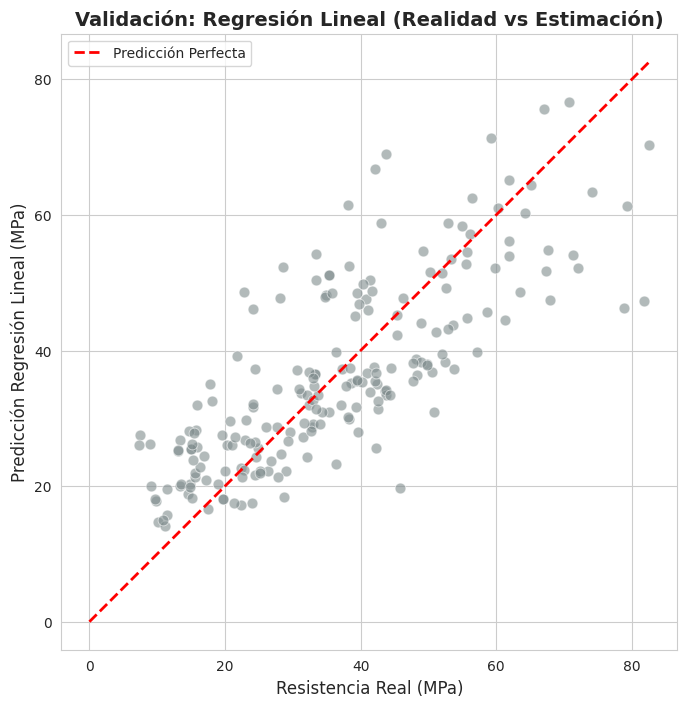

In [49]:
# Visualización: Realidad vs. Predicción
plot_real_vs_pred(modelo_lr, X_test, y_test, "Regresión Lineal", color='#7f8c8d')

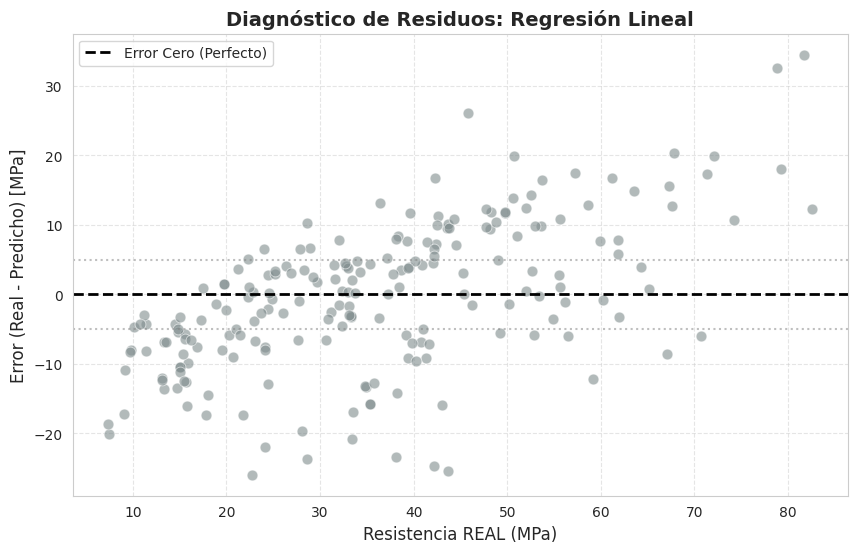

In [50]:
# Diagnóstico: Análisis de Residuos
# Crucial para ver que la relación en el hormigón NO es lineal
plot_residuals(modelo_lr, X_test, y_test, "Regresión Lineal", color='#7f8c8d')

/tmp/ipykernel_6713/3370554179.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')


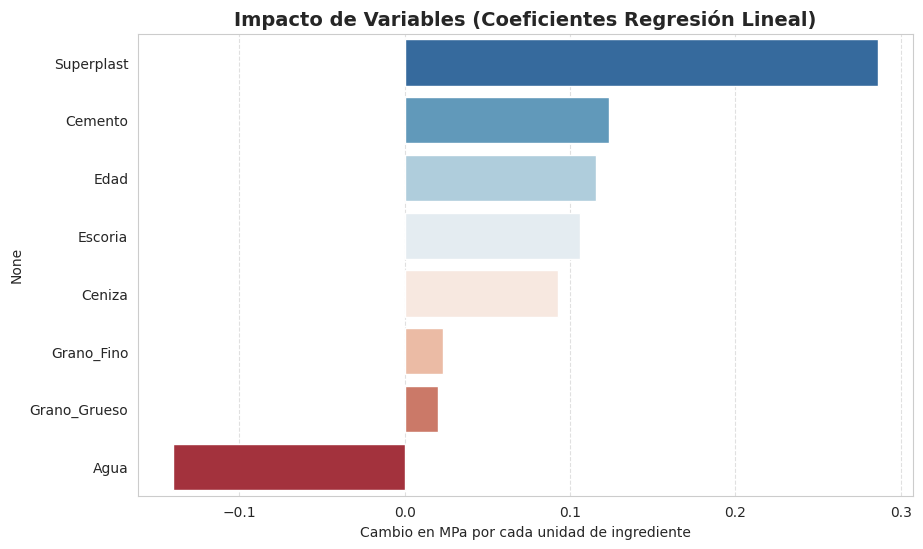

In [51]:
# Análisis de Coeficientes
# Extraemos los pesos que el modelo le da a cada ingrediente
coeficientes = pd.Series(modelo_lr.coef_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coeficientes.values, y=coeficientes.index, palette='RdBu_r')
plt.title('Impacto de Variables (Coeficientes Regresión Lineal)', fontsize=14, fontweight='bold')
plt.xlabel('Cambio en MPa por cada unidad de ingrediente')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [52]:
# Cálculo de Métricas y Registro en el Historial
metricas_lr = calcular_metricas(modelo_lr, X_test, y_test, "Regresión Lineal")
historial_modelos.append(metricas_lr)

### Comparación de modelos

In [54]:
# Mostrar la Tabla de Resultados Actualizada 
df_resultados = pd.DataFrame(historial_modelos).sort_values(by='R2 (Calidad)', ascending=False)
df_resultados

,Modelo,MAE (Error Medio),RMSE (Error Grande),R2 (Calidad)
1,XGBoost,2.710363,4.352416,0.933796
2,LightGBM,2.632990,4.359104,0.933592
0,Random Forest,3.299878,4.998944,0.912667
3,Regresión Lineal,8.386019,10.589347,0.608112
